In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os



from utils.participant_data import load_participant, load_all_participants
from utils.catchtrials import CatchTrials, add_conditions_by_sentence
from utils.gazedata import GazeData
from utils.pres_mapper import PresentationMapper  

In [2]:
conditions_df = pd.read_excel("data/sentences_newconditions.xlsx")

In [3]:
participants = load_all_participants()

print(participants.keys())

dict_keys(['01', '03', '04', '05', '06', '07', '08', '09', '10', '11'])


In [4]:
p = participants["01"]
print(p)                  # shows available/missing files

ParticipantData(participant_nr='01', available=['calibration', 'catch_trials', 'experiment', 'gaze', 'sentence_order'], missing=[])


# Catchtrials

In [5]:
REAL_ORDER_PATH = os.path.join("data", "sentences.js")

all_catch = []
gaze_by_participant = {}
mapper_by_participant = {}

for i in participants.keys():
    p = participants[i]

    df_ct = add_conditions_by_sentence(p.catch_trials, conditions_df)
    df_ct["participant_nr"] = i
    all_catch.append(df_ct)

    gaze_path = p.file_paths.get("gaze")
    if gaze_path is not None:
        gaze_by_participant[i] = GazeData(gaze_path)
    else:
        print(f"  WARNING: no gaze file for participant {i}, skipping in gaze_by_participant")

    # FIX: use sentence_order, not experiment
    exp_order_path = p.file_paths.get("sentence_order")
    if exp_order_path is not None:
        mapper_by_participant[i] = PresentationMapper(
            real_order_path=REAL_ORDER_PATH,
            exp_order_path=exp_order_path,
        )
    else:
        print(f"  WARNING: no sentence_order file for participant {i}, skipping in mapper_by_participant")

catch_all = pd.concat(all_catch, ignore_index=True)
print(catch_all.shape)
print(catch_all.columns.tolist())
print(f"gaze loaded for {len(gaze_by_participant)} participants, mapper for {len(mapper_by_participant)}")


[PresentationMapper] Initialising...
  real_order_path : data\sentences.js
  exp_order_path  : data\participant_01\sentence_order_01.csv
  Loaded 96 sentences from real_order
  First sentence : 'Sous le sapin, Alex trouve un cadeau mystérieux.'
  Last sentence  : 'Elle fait tomber son gâteau en le sortant du four.'
  exp_order shape : (96, 4)
  exp_order columns : ['real_index', 'presentation_index', 'first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                          first  real_index
                  0           Sophie arrive au bureau avec un sourire énigmatique.           6
                  1            Mafalda ne voit plus son fils dans l'eau de la mer.          51
                  2   La lecture du soir s'étire dans le calme de la bibliothèque.          66
                  3    Il ouvrit la porte après avoir entendu des voix familières.          38
                  4 En concert, le chanteur change soudain son progr

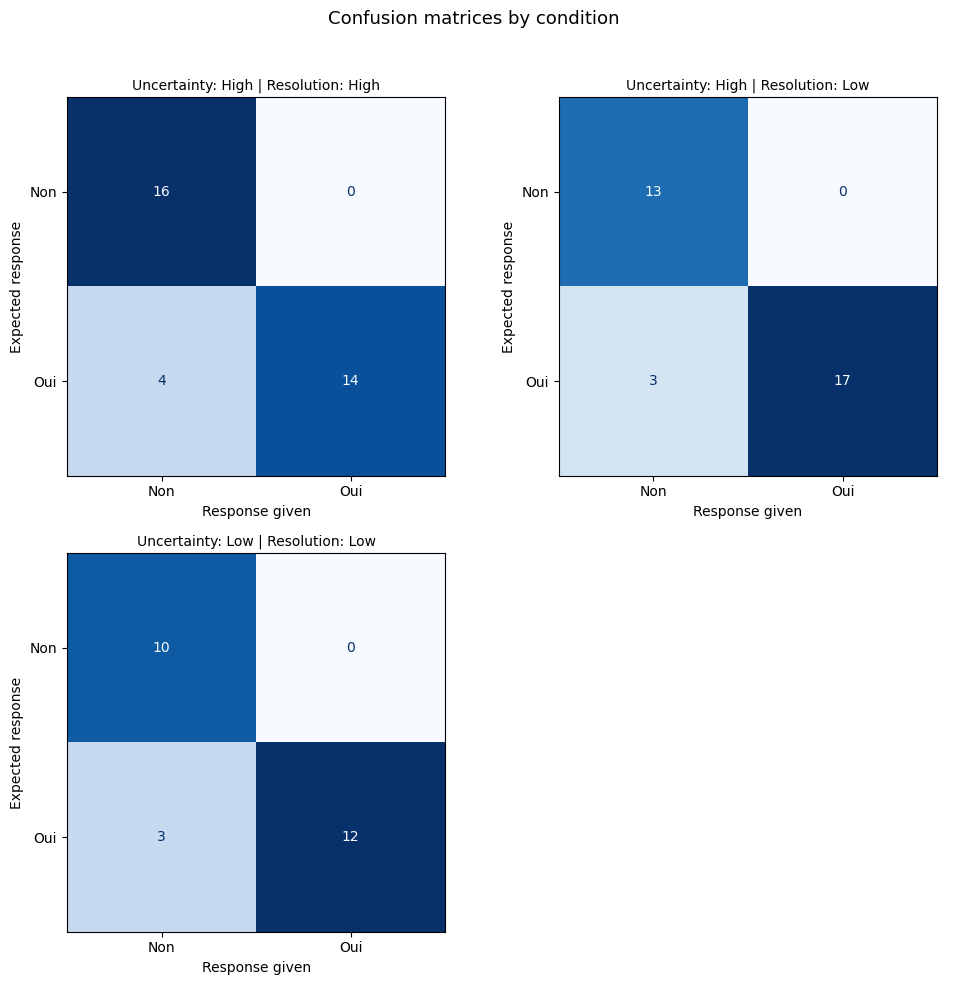

In [6]:
def plot_confusion_by_condition(df, condition_cols=["Uncertainty", "Resolution"],
                                 actual_col="correct_response", pred_col="response_label"):
    combos = df[condition_cols].drop_duplicates().sort_values(condition_cols).itertuples(index=False, name=None)
    combos = list(combos)

    labels = sorted(set(df[actual_col].dropna().unique()) | set(df[pred_col].dropna().unique()))

    n = len(combos)
    ncols = min(2, n) if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, combo in enumerate(combos):
        ax = axes_flat[ax_idx]
        mask = np.logical_and.reduce([df[c] == v for c, v in zip(condition_cols, combo)])
        sub = df[mask]

        cm = confusion_matrix(sub[actual_col], sub[pred_col], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_xlabel("Response given")
        ax.set_ylabel("Expected response")
        title = " | ".join(f"{c}: {v}" for c, v in zip(condition_cols, combo))
        ax.set_title(title, fontsize=10)

    for j in range(len(combos), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle("Confusion matrices by condition", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_confusion_by_condition(catch_all)

In [7]:
def plot_catch_type_vs_correct(df, title="Catch type vs Correct"):
    """Heatmap crosstab of catch_type against correct (accuracy)."""
    df = df.copy()
    df["correct"] = df["correct"].map({"true": True, "false": False, True: True, False: False})

    ct = pd.crosstab(df["catch_type"], df["correct"])
    ct = ct.astype(float)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(ct, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Correct")
    ax.set_ylabel("Catch type")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return ct

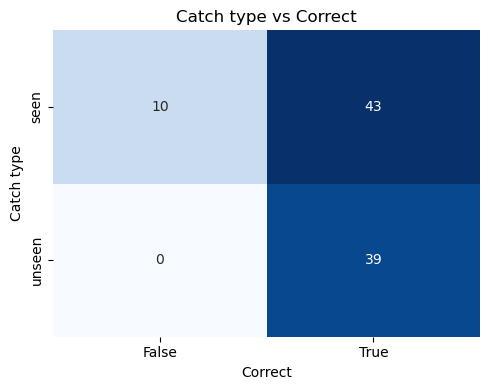

correct,False,True
catch_type,,
seen,10.0,43.0
unseen,0.0,39.0


In [8]:
plot_catch_type_vs_correct(catch_all)

In [9]:
def catch_trial_accuracy_stats(df, participant_col="participant_nr"):
    """Overall and per-participant catch trial accuracy stats."""
    df = df.copy()
    df["correct"] = df["correct"].map({"true": True, "false": False, True: True, False: False})

    overall_pct = df["correct"].mean() * 100
    print(f"Overall accuracy: {overall_pct:.1f}% ({df['correct'].sum()} / {len(df)} correct)")

    per_participant = (
        df.groupby(participant_col)["correct"]
        .agg(n_trials="count", n_correct="sum")
        .assign(pct_correct=lambda x: (x["n_correct"] / x["n_trials"] * 100).round(1))
        .sort_values("pct_correct")
    )

    print("\nPer-participant accuracy (worst to best):")
    print(per_participant)

    worst = per_participant.iloc[0]
    best = per_participant.iloc[-1]
    print(f"\nWorst performer: {per_participant.index[0]} — {worst['pct_correct']}% "
          f"({int(worst['n_correct'])}/{int(worst['n_trials'])})")
    print(f"Best performer: {per_participant.index[-1]} — {best['pct_correct']}% "
          f"({int(best['n_correct'])}/{int(best['n_trials'])})")

    return per_participant

per_participant_stats = catch_trial_accuracy_stats(catch_all)

Overall accuracy: 89.1% (82 / 92 correct)

Per-participant accuracy (worst to best):
                n_trials  n_correct  pct_correct
participant_nr                                  
11                     9          7         77.8
07                    10          8         80.0
06                    10          8         80.0
10                     8          7         87.5
04                     9          8         88.9
03                     9          8         88.9
01                     9          8         88.9
05                     9          9        100.0
09                     9          9        100.0
08                    10         10        100.0

Worst performer: 11 — 77.8% (7/9)
Best performer: 08 — 100.0% (10/10)


# Calibration data 

In [10]:
def build_calibration_df(participants):
    """Combine calibration records across all participants into one dataframe."""
    all_calib = []
    for participant_nr, p in participants.items():
        if p.calibration is None:
            print(f"WARNING: no calibration data for participant {participant_nr}")
            continue
        for record in p.calibration:
            row = record.copy()
            row["participant_nr"] = participant_nr
            all_calib.append(row)
    df = pd.DataFrame(all_calib)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

calib_all = build_calibration_df(participants)
print(calib_all.shape)
calib_all.head()

(50, 6)


,label,avg_error,valid_points,attempts,timestamp,participant_nr
0,initial,18.80,5,1,2026-07-20 08:43:09.888000+00:00,01
1,recalib_20,10.04,5,1,2026-07-20 08:48:10.654000+00:00,01
2,recalib_40,17.80,5,1,2026-07-20 08:52:33.414000+00:00,01
3,recalib_60,2.78,5,1,2026-07-20 08:56:33.024000+00:00,01
4,recalib_80,2.78,5,1,2026-07-20 09:00:39.896000+00:00,01


In [11]:
def calibration_overall_stats(df):
    print("=== Overall avg_error stats (all participants, all calibration points) ===")
    print(df["avg_error"].describe())

    print("\n=== Per-label avg_error stats (initial vs recalib_20/40/60/80...) ===")
    print(df.groupby("label")["avg_error"].describe())

    print("\n=== Per-participant mean avg_error ===")
    per_participant = df.groupby("participant_nr")["avg_error"].agg(["mean", "std", "min", "max", "count"]).round(2)
    per_participant = per_participant.sort_values("mean")
    print(per_participant)

    return per_participant

calib_stats = calibration_overall_stats(calib_all)

=== Overall avg_error stats (all participants, all calibration points) ===
count    50.000000
mean     16.994800
std       9.118867
min       2.780000
25%      12.992500
50%      15.305000
75%      18.350000
max      49.150000
Name: avg_error, dtype: float64

=== Per-label avg_error stats (initial vs recalib_20/40/60/80...) ===
            count    mean        std   min      25%     50%      75%    max
label                                                                      
initial      10.0  14.472   3.226425  8.21  13.7275  14.790  15.6450  18.80
recalib_20   10.0  13.879   3.881178  8.21  10.6925  14.660  15.4275  19.32
recalib_40   10.0  19.396   8.795661  9.15  13.4850  17.710  20.2575  37.72
recalib_60   10.0  19.865  14.326593  2.78  13.5025  15.775  18.1675  49.15
recalib_80   10.0  17.362  10.538946  2.78  13.0150  15.430  17.9900  39.93

=== Per-participant mean avg_error ===
                 mean    std    min    max  count
participant_nr                                  

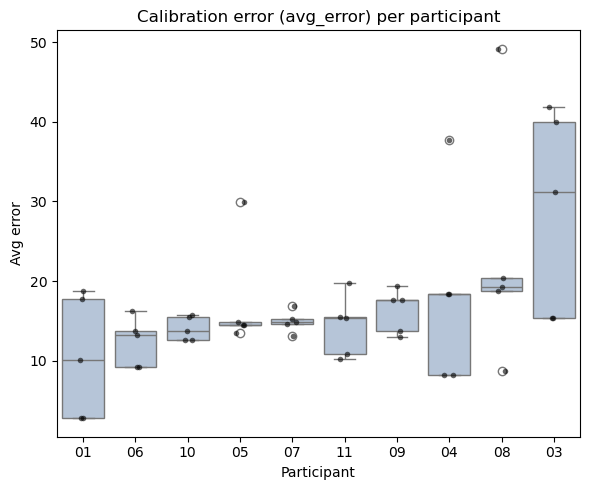

In [12]:
def plot_calibration_boxplot(df, title="Calibration error (avg_error) per participant"):
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * df["participant_nr"].nunique()), 5))

    order = df.groupby("participant_nr")["avg_error"].median().sort_values().index

    sns.boxplot(data=df, x="participant_nr", y="avg_error", order=order, ax=ax, color="lightsteelblue")
    sns.stripplot(data=df, x="participant_nr", y="avg_error", order=order, ax=ax, color="black", size=4, alpha=0.6)

    ax.set_xlabel("Participant")
    ax.set_ylabel("Avg error")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return 


plot_calibration_boxplot(calib_all)

# Reading times 

In [13]:
# reading times per conditions 

def build_reading_times_df(gaze_by_participant, mapper_by_participant, conditions_df):
    """
    gaze_by_participant:   {participant_id: GazeData}
    mapper_by_participant: {participant_id: PresentationMapper}
    conditions_df:         DataFrame with columns
                            ["Uncertainty", "Resolution", "Unc Valence", "Res Valence",
                             "Part 1", "Part 2"], where real_index = row position
                            (NOT a column — same fix as the earlier merge bug).

    Returns one long DataFrame:
        participant_id, pres, real_index, onset, offset, duration,
        Uncertainty, Resolution, Unc Valence, Res Valence
    """
    # real_index = row order, made explicit as its own column for merging
    conditions = conditions_df.reset_index(drop=True).copy()
    conditions["real_index"] = conditions.index

    rows = []
    for pid, gd in gaze_by_participant.items():
        mapper = mapper_by_participant[pid]
        pres_to_real = mapper.get_pres_to_real_map()

        # 1. duration per presentation_index (from onset/offset triggers)
        durations = gd.sentence_durations()  # columns: pres, onset, offset, duration

        # 2. map presentation_index -> real_index
        durations["real_index"] = durations["pres"].map(pres_to_real)

        unmapped = durations["real_index"].isna().sum()
        if unmapped:
            print(f"[{pid}] Warning: {unmapped} presentation(s) had no real_index mapping.")

        durations.insert(0, "participant_id", pid)
        rows.append(durations)

    full = pd.concat(rows, ignore_index=True)

    # 3. combine conditions onto the timed rows via real_index
    before_n = len(full)
    full = full.merge(
        conditions[["real_index", "Uncertainty", "Resolution", "Unc Valence", "Res Valence"]],
        on="real_index",
        how="left"
    )
    unmatched = full["Uncertainty"].isna().sum()
    if unmatched:
        print(f"Warning: {unmatched}/{before_n} rows had no matching condition metadata.")

    return full

In [24]:
# 1. Build the long reading-times table (duration per presentation, mapped to real_index,
#    joined with Uncertainty / Resolution / Unc Valence / Res Valence)
reading_times_df = build_reading_times_df(
    gaze_by_participant,
    mapper_by_participant,
    conditions_df,
)

print(reading_times_df.shape)
print(reading_times_df.head())

reading_times_df.to_csv("data/reading_times_for_r.csv", index=False)

(960, 10)
  participant_id  pres       onset      offset  duration  real_index  \
0             01     0  2364.33521  2368.83643      4.50           6   
1             01     1  2370.83154  2376.68433      5.85          51   
2             01     2  2378.69629  2383.59277      4.90          66   
3             01     3  2385.58789  2390.08911      4.50          38   
4             01     4  2392.10107  2397.29443      5.19           1   

  Uncertainty Resolution Unc Valence Res Valence  
0        High       High         Pos         Pos  
1        High        Low         Neg         Pos  
2         Low        Low         Pos         Pos  
3        High        Low         Pos         Pos  
4        High       High         Pos         Pos  


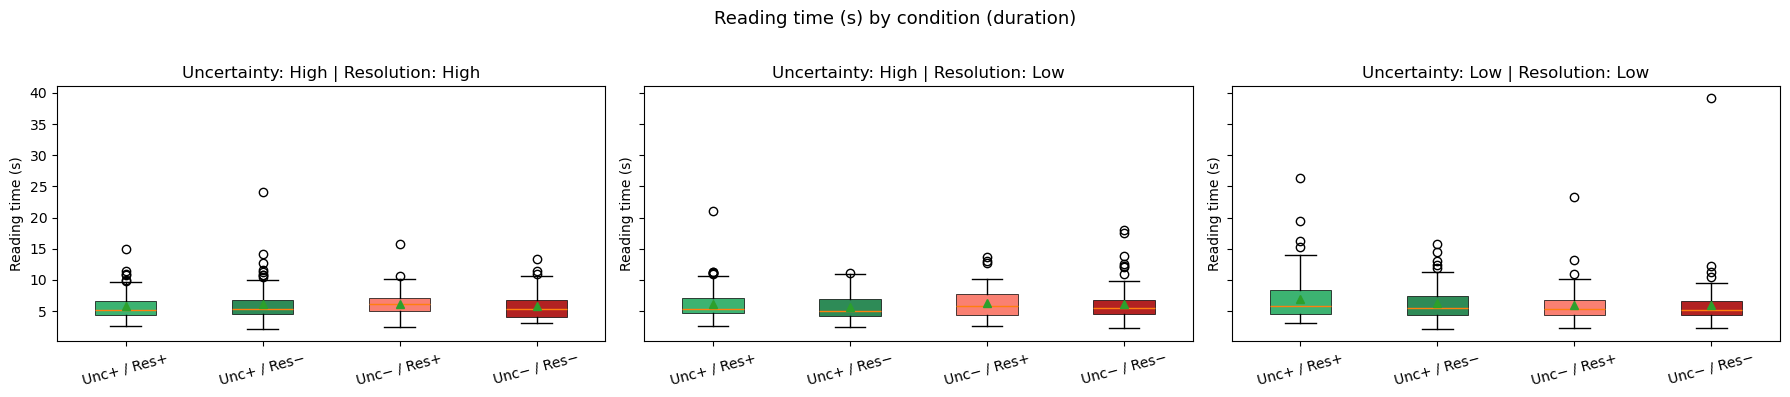

In [21]:
def plot_reading_times_boxplot_by_condition(df, metric="duration", ylabel="Reading time (s)"):
    """Boxplot of raw metric values, one subplot per existing Uncertainty x
    Resolution combination, all in a single row. Within each subplot, four
    boxes covering all Unc Valence x Res Valence combinations."""

    combos = df[["Uncertainty", "Resolution"]].drop_duplicates().sort_values(
        ["Uncertainty", "Resolution"]
    ).itertuples(index=False, name=None)
    combos = list(combos)

    n = len(combos)
    ncols = n if n > 0 else 1
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False, sharey=True)
    axes_flat = axes.flatten()

    bar_specs = [
        ("pos", "pos", "Unc+ / Res+", "mediumseagreen"),
        ("pos", "neg", "Unc+ / Res−", "seagreen"),
        ("neg", "pos", "Unc− / Res+", "salmon"),
        ("neg", "neg", "Unc− / Res−", "firebrick"),
    ]
    bar_labels = [spec[2] for spec in bar_specs]
    bar_colors = [spec[3] for spec in bar_specs]

    def get_values(sub, unc_val_prefix, res_val_prefix):
        row = sub[
            sub["Unc Valence"].str.lower().str.startswith(unc_val_prefix)
            & sub["Res Valence"].str.lower().str.startswith(res_val_prefix)
        ]
        return row[metric].dropna().values

    all_values = []
    subplot_data = []
    for unc, res in combos:
        sub = df[(df["Uncertainty"] == unc) & (df["Resolution"] == res)]
        values = [get_values(sub, u, r) for u, r, _, _ in bar_specs]
        subplot_data.append((unc, res, values))
        for v in values:
            all_values.extend(v)

    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        pad = (y_max - y_min) * 0.05
        y_lim = (y_min - pad, y_max + pad)
    else:
        y_lim = (0, 1)

    for ax_idx, (unc, res, values) in enumerate(subplot_data):
        ax = axes_flat[ax_idx]
        bp = ax.boxplot(values, tick_labels=bar_labels, showmeans=True, patch_artist=True)
        for patch, color in zip(bp["boxes"], bar_colors):
            patch.set_facecolor(color)
            patch.set_edgecolor("black")
            patch.set_linewidth(0.5)
        ax.set_ylim(y_lim)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Uncertainty: {unc} | Resolution: {res}")
        ax.tick_params(axis="x", rotation=15)

    for j in range(len(combos), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{ylabel} by condition ({metric})", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return

# 2. Boxplot: reading time per condition, faceted by Uncertainty x Resolution
plot_reading_times_boxplot_by_condition(
    reading_times_df,
    metric="duration",
    ylabel="Reading time (s)",
)

# gaze analysis - fixations and gaze on screen